# 10 &middot; Resolution and Cost: the Accuracy/Speed Trade-off

Refining a mesh makes a simulation more accurate, but every solve more expensive. On a soft cantilever
sagging under gravity, we measure Newton-solve time and tip-deflection error at ten resolutions against
a very fine reference, and see why a super-fine mesh is accurate but **too slow to iterate on**.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import igl
import simkit
import utils

NOTEBOOK = "010_time_complexity"                                   # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)    # results/010_time_complexity/
MEDIA_DIR = "media"                                                # tracked copies for the website
# beam and material
WIDTH, HEIGHT = 2.0, 0.3                     # cantilever size
YM, PR = 800.0, 0.4                          # Young's modulus (soft -> large, obvious sag), Poisson ratio
RHO = 1.0                                    # density
GRAVITY = -9.8                               # vertical acceleration
MATERIAL = "macklin-mueller-neo-hookean"     # simkit elastic material
K_PIN = 1e7                                  # soft-pin stiffness on the left edge
# Newton solve
NEWTON_ITERS = 30                            # max Newton iterations per static solve
NEWTON_TOL = 1e-6                            # stop once the step norm drops below this
# resolution sweep: (nx, ny) = vertices along the length / height
RESOLUTIONS = [(5, 2), (7, 3), (10, 4), (14, 5), (19, 6), (26, 9), (34, 11), (44, 15), (56, 19), (70, 23)]
REF_RES = (90, 30)                           # fine "ground truth" mesh
I_GOOD = 4                                   # index into RESOLUTIONS of the "good enough" mesh
# animation
ANIM_MESHES = [(7, 3, "coarse"), (16, 6, "medium"), (32, 11, "fine")]
RAMP_FRAMES, HOLD_FRAMES = 22, 12            # gravity ramps 0 -> 1, then holds at full gravity
FPS = 20                                     # video frame rate

## The beam and its meshes

`beam_mesh` lays an `nx × ny` vertex grid over the beam (libigl's unit-square grid, centered and
scaled). It also returns the left-edge vertices we pin and the bottom-right **tip** vertex whose height
$y$ we measure.

In [2]:
def beam_mesh(nx, ny):
    """nx x ny vertex grid over the WIDTH x HEIGHT beam, its pinned left edge and its tip vertex."""
    V, T = igl.triangulated_grid(nx, ny)
    X = (V - 0.5) * np.array([WIDTH, HEIGHT])
    pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
    tip_idx = int(np.argmax(X[:, 0]))
    return X, T, pin_idx, tip_idx

Every mesh this notebook solves on, at rest: the ten sweep resolutions, the fine reference, and the two
extra animation meshes (the coarse animation beam reuses the 7×3 sweep mesh). Blue squares mark the
pinned left edge and the red star marks the measured tip.

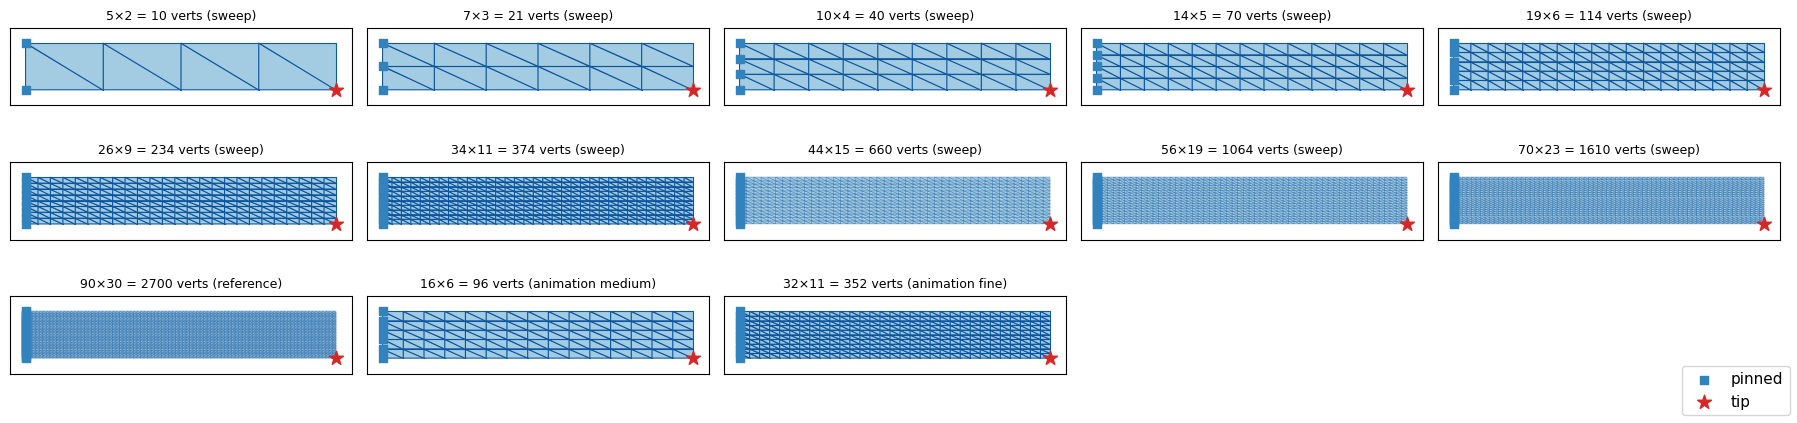

In [3]:
mesh_panels = [(res, "sweep") for res in RESOLUTIONS] + [(REF_RES, "reference")]
mesh_panels += [((nx, ny), f"animation {label}") for nx, ny, label in ANIM_MESHES if (nx, ny) not in RESOLUTIONS]

fig, axes = plt.subplots(3, 5, figsize=(18, 4.4))
for ax, ((nx, ny), role) in zip(axes.flat, mesh_panels):
    X, T, pin_idx, tip_idx = beam_mesh(nx, ny)
    utils.plot_mesh(ax, X, T, pins=pin_idx, lw=0.8 if nx < 40 else 0.2,
                    title=f"{nx}×{ny} = {len(X)} verts ({role})")
    ax.scatter(*X[tip_idx], marker="*", s=110, color="#d62728", zorder=6, label="tip")
    ax.get_legend().remove()
    ax.title.set_fontsize(9)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[len(mesh_panels):]:
    ax.axis("off")
fig.legend(*axes.flat[0].get_legend_handles_labels(), loc="lower right", fontsize=11)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "010_meshes.png"))
plt.show()

## The system: elastic + pin + gravity

`gravity_beam_system` is our standard static cantilever. It precomputes the per-mesh operators once and
returns closures for the energy, gradient and Hessian of three terms: the elastic material, a stiff
quadratic **pin** on the left edge, and **gravity**. Gravity is linear in $x$, so it adds no Hessian
term. `gravity_scale` lets the animation ramp gravity up.

$$E(x) = \Psi_{\text{elastic}}(x) + \tfrac{k_{\text{pin}}}{2}\,\|x_{\text{pin}} - X_{\text{pin}}\|^2 - f_g^\top x$$

In [4]:
def gravity_beam_system(X, T, pin_idx, gravity_scale=1.0):
    """Cantilever under gravity: elastic + soft pin on the left edge + gravity, in stacked positions x."""
    n, dim = X.shape
    J = simkit.deformation_jacobian(X, T)
    vol = simkit.volume(X, T)
    mu_s, lam_s = simkit.ympr_to_lame(YM, PR)
    mu = np.full((len(T), 1), mu_s)
    lam = np.full((len(T), 1), lam_s)
    Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)
    f_g = gravity_scale * simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1)

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_gravity = -(f_g.T @ x).item()
        E_total = E_elastic + E_pin + E_gravity
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_gravity = -f_g
        g_total = g_elastic + g_pin + g_gravity
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_total = H_elastic + H_pin
        return H_total

    return energy_func, gradient_func, hessian_func

`timed_static_solve` builds the beam at one resolution and times **only** the Newton solve from the rest
shape, using `time.perf_counter`. It records the vertex count, the Newton iteration count, the gradient
norm at every iteration, and the tip height.

In [5]:
def timed_static_solve(nx, ny, gravity_scale=1.0):
    """Build the nx x ny beam and its system, then time one Newton solve starting from rest."""
    X, T, pin_idx, tip_idx = beam_mesh(nx, ny)
    energy_func, gradient_func, hessian_func = gravity_beam_system(X, T, pin_idx, gravity_scale)
    t0 = time.perf_counter()
    # silence spurious floating-point flags raised by BLAS matmuls on large vectors (all values stay finite)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        x, info = simkit.solvers.newton_solver(X.reshape(-1, 1), energy_func, gradient_func, hessian_func,
                                               tolerance=NEWTON_TOL, max_iter=NEWTON_ITERS,
                                               do_line_search=True, return_info=True)
    seconds = time.perf_counter() - t0
    U = x.reshape(X.shape)
    grad_norms = [np.linalg.norm(g) for g in info["g"]] + [np.linalg.norm(gradient_func(x))]
    return dict(X=X, T=T, U=U, n=len(X), seconds=seconds, iters=info["iters"] + 1,
                grad_norms=grad_norms, tip_y=U[tip_idx, 1])

## Cost and accuracy across 10 resolutions

Run the sweep and the fine reference. The **error** of each run is the distance between its tip height
and the reference tip height. The table lists the vertex count, solve time, Newton iterations, tip
height and error for each run.

In [6]:
sweep = [timed_static_solve(nx, ny) for nx, ny in RESOLUTIONS]
ref = timed_static_solve(*REF_RES)

verts = np.array([run["n"] for run in sweep])
times = np.array([run["seconds"] for run in sweep])
iters = np.array([run["iters"] for run in sweep])
errors = np.array([abs(run["tip_y"] - ref["tip_y"]) for run in sweep])

print(f"fine reference: {ref['n']} verts, {ref['seconds']*1000:.0f} ms, {ref['iters']} Newton iters, tip_y = {ref['tip_y']:.4f}")
for run, err in zip(sweep, errors):
    print(f"  {run['n']:5d} verts   {run['seconds']*1000:7.1f} ms   {run['iters']:2d} iters   "
          f"tip_y {run['tip_y']:.4f}   error {err:.2e}")

fine reference: 2700 verts, 722 ms, 26 Newton iters, tip_y = -1.5921
     10 verts       4.3 ms   12 iters   tip_y -0.5823   error 1.01e+00
     21 verts       6.6 ms   17 iters   tip_y -0.9618   error 6.30e-01
     40 verts       9.7 ms   20 iters   tip_y -1.2361   error 3.56e-01
     70 verts      15.3 ms   22 iters   tip_y -1.3884   error 2.04e-01
    114 verts      26.3 ms   26 iters   tip_y -1.4685   error 1.24e-01
    234 verts      52.8 ms   27 iters   tip_y -1.5326   error 5.95e-02
    374 verts      70.4 ms   23 iters   tip_y -1.5567   error 3.54e-02
    660 verts     170.1 ms   30 iters   tip_y -1.5738   error 1.83e-02
   1064 verts     247.6 ms   26 iters   tip_y -1.5828   error 9.31e-03
   1610 verts     338.7 ms   22 iters   tip_y -1.5880   error 4.10e-03


## Compute time vs resolution, and accuracy vs resolution

Both plots use log-log axes with dashed reference slopes. Solve time grows about linearly with the vertex
count at these sizes (left), while the tip error falls roughly like $O(1/n)$ (right), so each extra digit
of accuracy costs about ten times more compute.

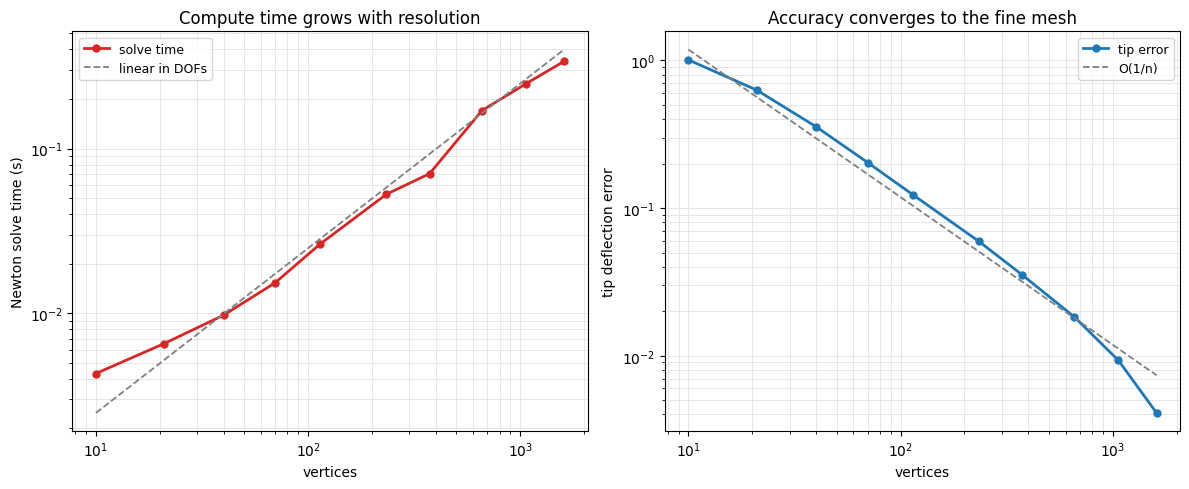

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
utils.loglog_plot(verts, {"solve time": times}, xlabel="vertices", ylabel="Newton solve time (s)",
                  colors={"solve time": "#d62728"}, ref_slopes={"linear in DOFs": 1},
                  title="Compute time grows with resolution", ax=axes[0])
utils.loglog_plot(verts, {"tip error": errors}, xlabel="vertices", ylabel="tip deflection error",
                  colors={"tip error": "#1f77b4"}, ref_slopes={"O(1/n)": -1},
                  title="Accuracy converges to the fine mesh", ax=axes[1])
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "cost_accuracy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "010_cost_accuracy.png"))
plt.show()

## Where the time goes: Newton iterations

Validation: at every resolution the gradient norm (left) falls by four to six orders of magnitude before
the Newton step drops below `NEWTON_TOL`. The iteration count grows only mildly (12 on the coarsest mesh,
20–30 from 40 vertices up), so solve time grows mostly through the cost of **one iteration** (right). Each
iteration does a Hessian assembly, a bigger sparse solve and a few line-search energy evaluations. Fixed
per-call overhead dominates only at the smallest sizes.

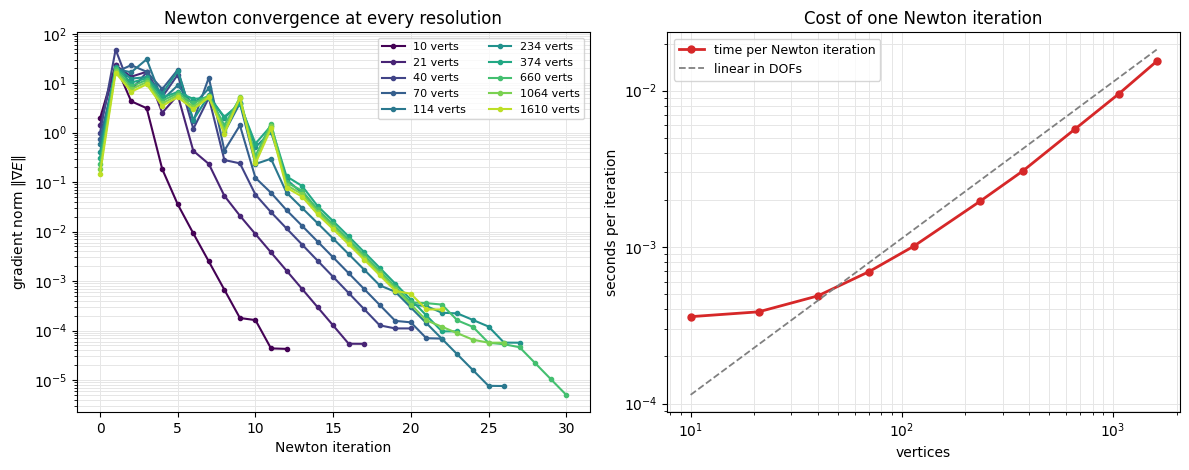

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for run, color in zip(sweep, plt.cm.viridis(np.linspace(0.0, 0.9, len(sweep)))):
    axes[0].semilogy(run["grad_norms"], "-o", ms=3, color=color, label=f"{run['n']} verts")
axes[0].set(xlabel="Newton iteration", ylabel=r"gradient norm $\|\nabla E\|$",
            title="Newton convergence at every resolution")
axes[0].grid(True, which="both", color="0.9", linewidth=0.7)
axes[0].legend(fontsize=8, ncol=2)
utils.loglog_plot(verts, {"time per Newton iteration": times / iters}, xlabel="vertices",
                  ylabel="seconds per iteration", colors={"time per Newton iteration": "#d62728"},
                  ref_slopes={"linear in DOFs": 1}, title="Cost of one Newton iteration", ax=axes[1])
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "newton_iterations.png"),
                              copy_to=os.path.join(MEDIA_DIR, "010_newton_iterations.png"))
plt.show()

## Watching three resolutions sag under gravity

Ramp gravity $0 \rightarrow 1$ and solve each frame from rest at three resolutions, then **hold at full
gravity** so every beam settles into its final equilibrium. Each panel title gives the average solve time
per frame.

In [9]:
gravity_ramp = np.concatenate([np.linspace(0.0, 1.0, RAMP_FRAMES), np.ones(HOLD_FRAMES)])
anim_runs = {label: [timed_static_solve(nx, ny, g) for g in gravity_ramp] for nx, ny, label in ANIM_MESHES}

panels = [{"states": [run["U"] for run in runs], "T": runs[0]["T"],
           "title": f"{label}: {runs[0]['n']} verts, {1000*np.mean([run['seconds'] for run in runs]):.0f} ms/solve"}
          for label, runs in anim_runs.items()]
fig, anim = utils.animate_meshes_grid(panels, lims=((-1.2, 1.2), (-1.8, 0.3)), fps=FPS,
                                      suptitle="Same beam, three resolutions, sagging under gravity")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "resolution.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "010_resolution.mp4"))
plt.close(fig)
utils.embed_video(video)

The medium and fine beams settle into nearly the same large droop. The coarse one sags much less, because a
few large linear triangles are too stiff in bending. The next plot shows this frame by frame. On the left,
the coarse tip stops near $y=-0.96$, far above the reference's $-1.59$ (dashed). On the right, each finer
mesh costs roughly 3–4× more per frame.

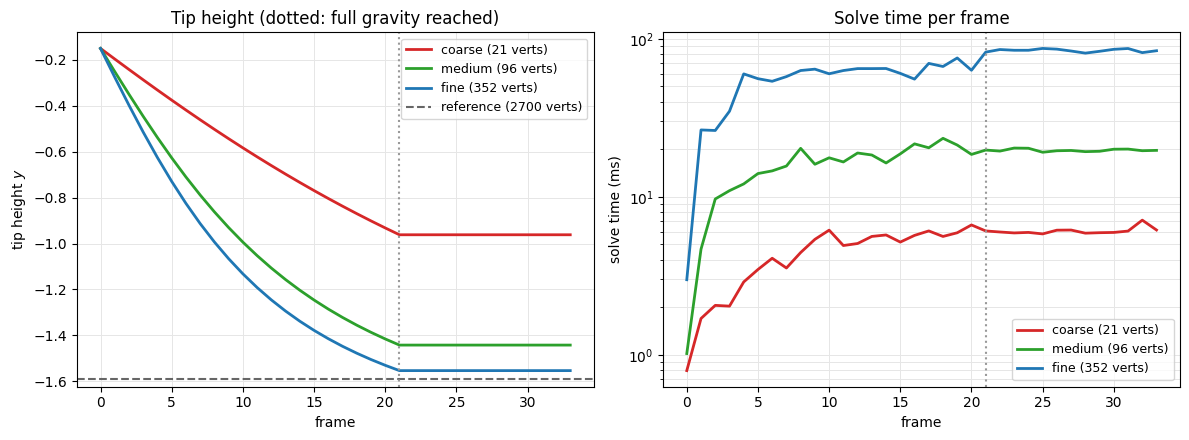

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for (label, runs), color in zip(anim_runs.items(), ["#d62728", "#2ca02c", "#1f77b4"]):
    name = f"{label} ({runs[0]['n']} verts)"
    axes[0].plot([run["tip_y"] for run in runs], "-", lw=2, color=color, label=name)
    axes[1].semilogy([1000 * run["seconds"] for run in runs], "-", lw=2, color=color, label=name)
axes[0].axhline(ref["tip_y"], ls="--", color="0.4", label=f"reference ({ref['n']} verts)")
axes[0].axvline(RAMP_FRAMES - 1, ls=":", color="0.6")
axes[1].axvline(RAMP_FRAMES - 1, ls=":", color="0.6")
axes[0].set(xlabel="frame", ylabel="tip height $y$", title="Tip height (dotted: full gravity reached)")
axes[1].set(xlabel="frame", ylabel="solve time (ms)", title="Solve time per frame")
for ax in axes:
    ax.grid(True, which="both", color="0.9", linewidth=0.7)
    ax.legend(fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "animation_tip_and_time.png"),
                              copy_to=os.path.join(MEDIA_DIR, "010_animation_tip_and_time.png"))
plt.show()

## Why "just refine it" is a trap

Compare the mid-resolution "good enough" run (`I_GOOD`) with the fine reference, in time per solve and
in tip error.

In [11]:
good = sweep[I_GOOD]
rel = errors[I_GOOD] / abs(ref["tip_y"])
print(f"good-enough ({good['n']:5d} verts): {good['seconds']*1000:8.1f} ms/solve   ({rel*100:.0f}% tip error)")
print(f"fine        ({ref['n']:5d} verts): {ref['seconds']*1000:8.1f} ms/solve")
print(f"\nThe fine mesh is ~{ref['seconds']/good['seconds']:.0f}x slower per solve for a tip deflection")
print(f"within {rel*100:.0f}% of it. Interactive editing (many solves/second) is impossible")
print("long before that accuracy is worth it -- pick the coarsest mesh that captures the behavior.")

good-enough (  114 verts):     26.3 ms/solve   (8% tip error)
fine        ( 2700 verts):    722.5 ms/solve

The fine mesh is ~27x slower per solve for a tip deflection
within 8% of it. Interactive editing (many solves/second) is impossible
long before that accuracy is worth it -- pick the coarsest mesh that captures the behavior.


The fields agree as well, drawn on the deformed good-enough mesh (top) and reference mesh (bottom). The
gravity load $|f_g|$ is lumped mass × $g$, so it is smaller on the boundary and is split among more
vertices on the fine mesh. Displacement and energy density share color scales across the rows. Bending
energy concentrates in the top and bottom fibers near the clamped root, around a low-energy neutral axis.
The printout checks that $\sum_e \psi_e\,\mathrm{vol}_e$ equals the elastic energy the solver minimized.

  114 verts: sum(psi * vol) = 1.4002   elastic_energy_x = 1.4002
 2700 verts: sum(psi * vol) = 1.4579   elastic_energy_x = 1.4579


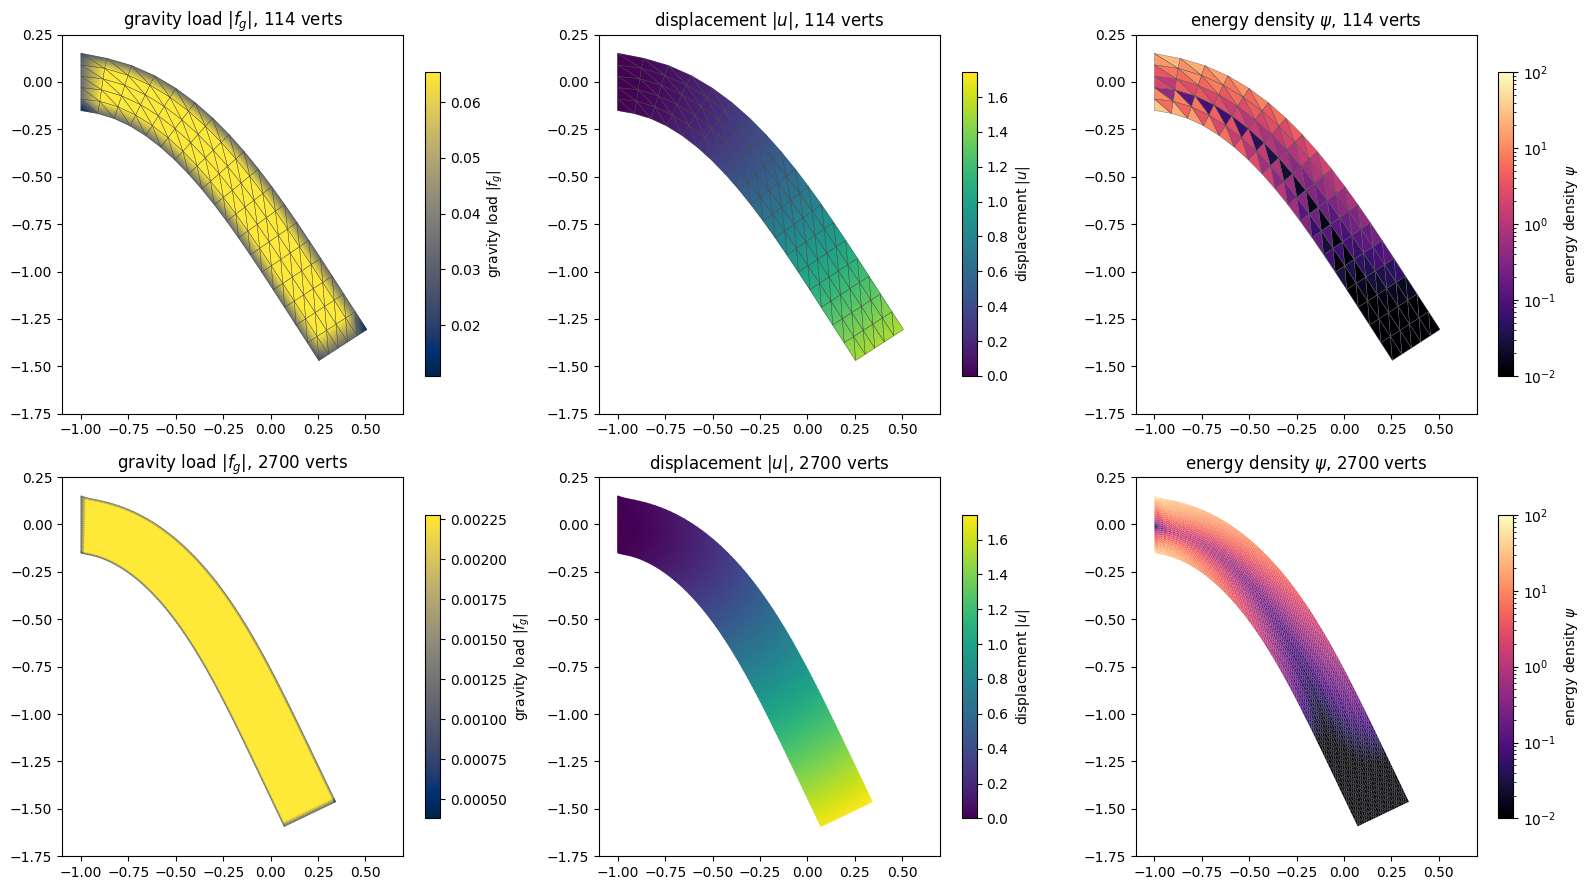

In [12]:
mu_s, lam_s = simkit.ympr_to_lame(YM, PR)
disp_max = np.linalg.norm(ref["U"] - ref["X"], axis=1).max()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for row, run in zip(axes, [good, ref]):
    X, T, U = run["X"], run["T"], run["U"]
    f_g = simkit.gravity_force(X, T, a=GRAVITY, rho=RHO)
    F = simkit.deformation_gradient(X, T, U)
    mu, lam = np.full((len(T), 1), mu_s), np.full((len(T), 1), lam_s)
    psi = simkit.energies.elastic_energy_element_F(F, mu, lam, MATERIAL)
    vol = simkit.volume(X, T)
    E_elastic = simkit.energies.elastic_energy_x(U, simkit.deformation_jacobian(X, T), mu, lam, vol, MATERIAL)
    print(f"{run['n']:5d} verts: sum(psi * vol) = {(psi * vol).sum():.4f}   elastic_energy_x = {E_elastic:.4f}")
    fields = [
        (np.linalg.norm(f_g, axis=1), "gravity load $|f_g|$", dict(cmap="cividis")),
        (np.linalg.norm(U - X, axis=1), "displacement $|u|$", dict(vmin=0.0, vmax=disp_max)),
        (psi, r"energy density $\psi$", dict(cmap="magma", norm=LogNorm(1e-2, 1e2))),
    ]
    for ax, (values, label, style) in zip(row, fields):
        utils.plot_scalar_field(ax, U, T, values, title=f"{label}, {run['n']} verts", label=label,
                                edges=run["n"] < 500, lims=((-1.1, 0.7), (-1.75, 0.25)), **style)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "equilibrium_fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "010_equilibrium_fields.png"))
plt.show()

### Takeaways
* **Cost** rises steeply with vertex count. Newton needs only mildly more iterations on finer meshes,
  but each iteration assembles and solves a bigger sparse system.
* **Accuracy** improves with resolution, but with diminishing returns (tip error falls roughly like $O(1/n)$).
* A super-fine mesh is accurate yet **too slow to iterate on**. Pick the coarsest mesh that captures the behavior.